In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parent
sys.path.insert(0, str(ROOT_DIR))

In [7]:
from src.baseline_model import train_baseline

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [17]:
font_path = "C:/Windows/Fonts/malgun.ttf"

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'retina'

In [9]:
train = pd.read_csv(ROOT_DIR / "data" / "ratings_train.txt", sep="\t")
train = train.dropna()

print("Train shape:", train.shape)
print(train.head())

Train shape: (149995, 3)
         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1


In [ ]:
model, vectorizer, acc = train_baseline(train)
print(f"Baseline Accuracy: {acc:.4f}")

Baseline Accuracy: 0.7928


#### Confusion Matrix

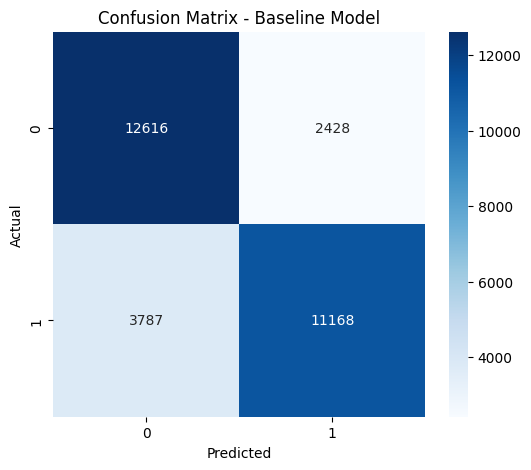

In [13]:
# validation set 분리
X_train, X_val, y_train, y_val = train_test_split(
    train["document"], train["label"], test_size=0.2, random_state=42
)
X_val_vec = vectorizer.transform(X_val)
y_pred = model.predict(X_val_vec)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Model")
plt.show()

#### Sample

In [ ]:
sample_texts = [
    "이 영화 정말 재미있어요!",
    "진짜 시간 낭비였어요...",
    "배우 연기가 훌륭했어요",
    "스토리가 너무 지루하고 예상 가능했어요"
]

sample_vec = vectorizer.transform(sample_texts)
sample_pred = model.predict(sample_vec)

print("results")
for text, pred in zip(sample_texts, sample_pred):
    label = "긍정" if pred==1 else "부정"
    print(f"- 텍스트: {text}\n  예측: {label}\n")

Sample Predictions:
- 텍스트: 이 영화 정말 재미있어요!
  예측: 긍정

- 텍스트: 진짜 시간 낭비였어요...
  예측: 부정

- 텍스트: 배우 연기가 훌륭했어요
  예측: 긍정

- 텍스트: 스토리가 너무 지루하고 예상 가능했어요
  예측: 부정



#### TF-IDF 상위 20 단어

In [15]:
# feature names와 가중치 확인
tfidf_feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

# 긍정/부정 영향 상위 단어 추출
coef_df = pd.DataFrame({"word": tfidf_feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
top_features = coef_df.sort_values(by="abs_coef", ascending=False).head(20)

C:\Users\color\AppData\Local\Temp\ipykernel_31892\2590647423.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="coef", y="word", data=top_features, palette="coolwarm")


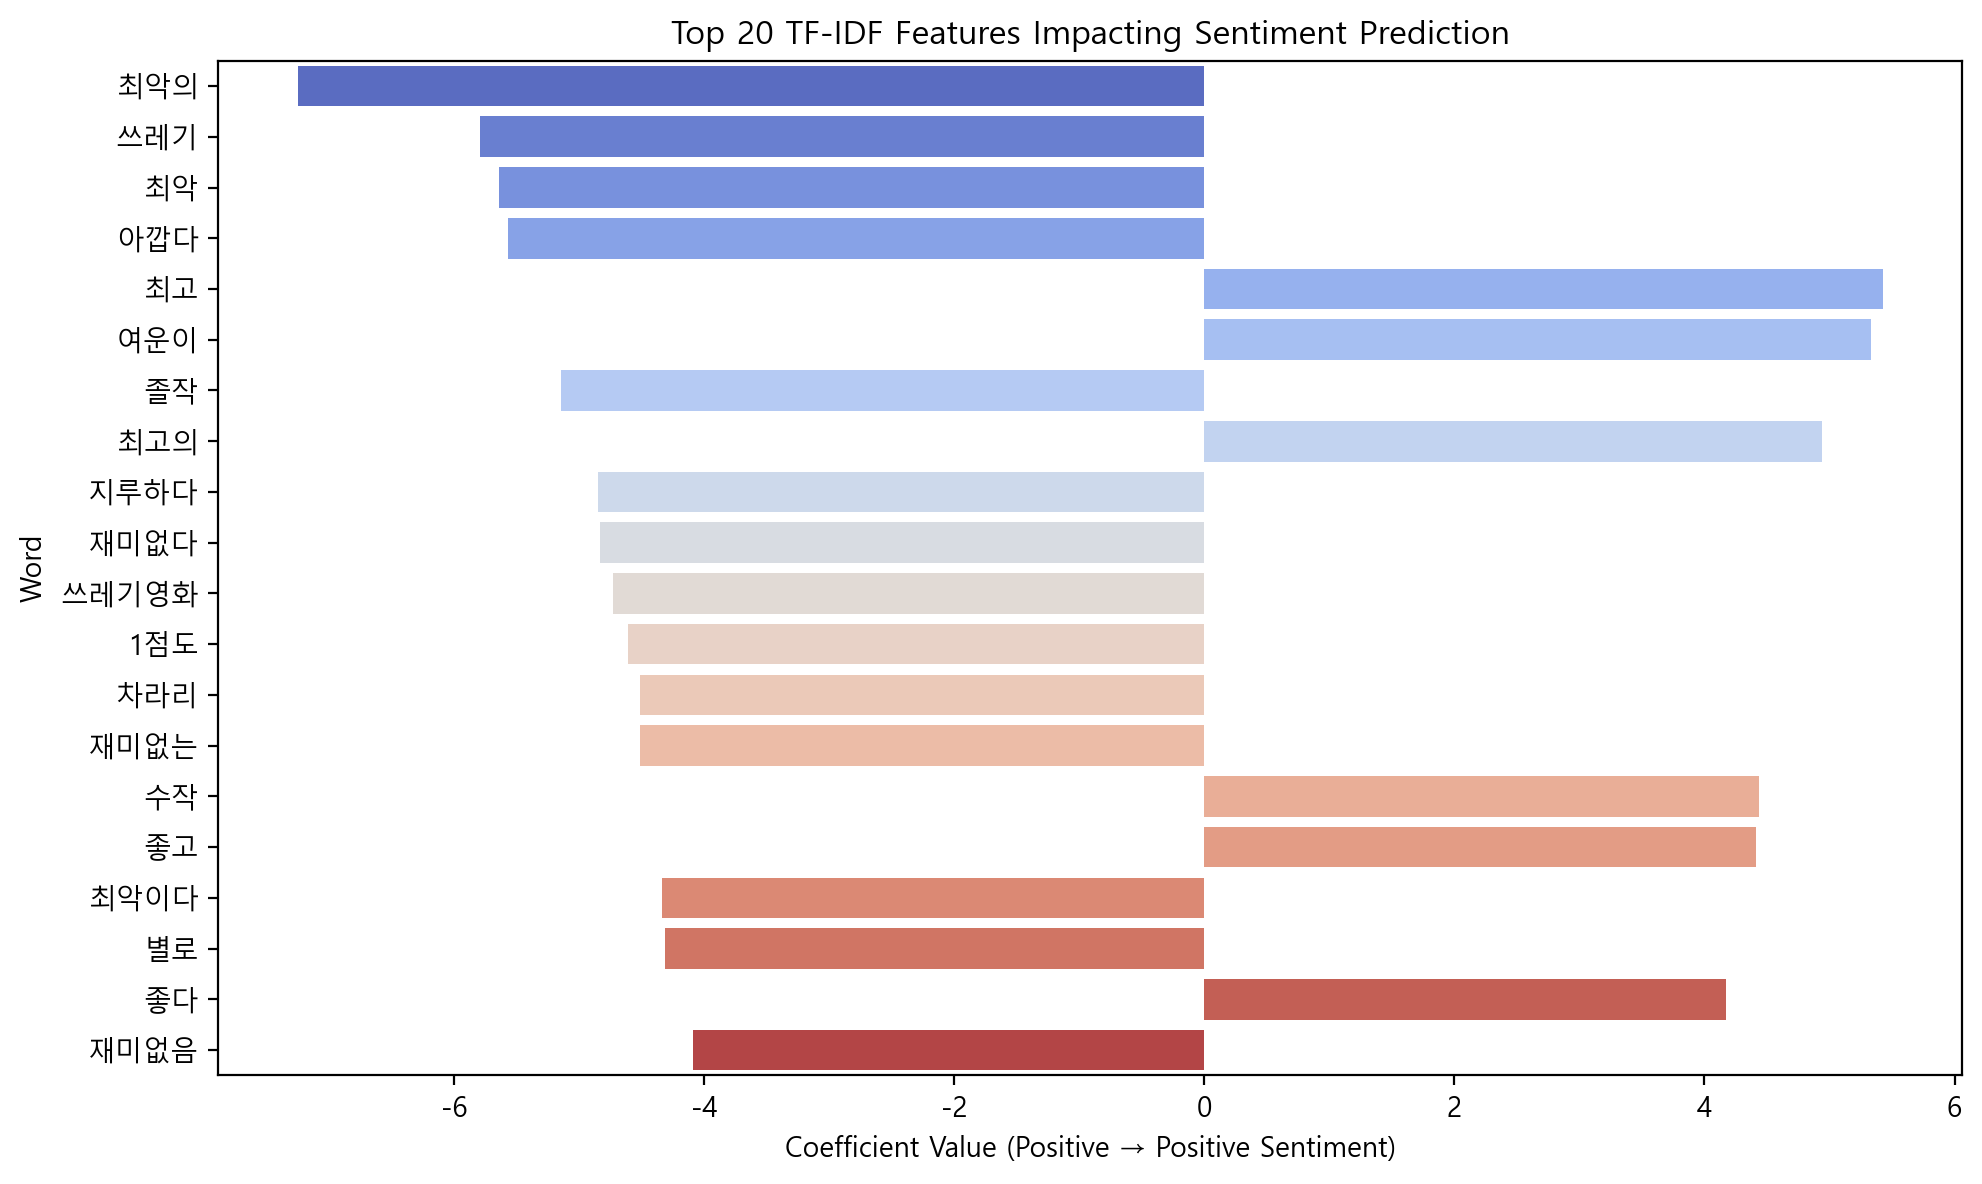

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(x="coef", y="word", data=top_features, palette="coolwarm")
plt.title("Top 20 TF-IDF Features Impacting Sentiment Prediction")
plt.xlabel("Coefficient Value (Positive → Positive Sentiment)")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

In [ ]:
# save results
RESULTS_DIR = ROOT_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

train[['document', 'label']].to_csv(RESULTS_DIR / 'train_preprocessed.csv', index=False)
coef_df.to_csv(RESULTS_DIR / 'tfidf_features.csv', index=False)
